# 10 — FedAvg Simulation (CICIoT2023 cat8)

## Why FedAvg first?

**Federated Averaging (FedAvg, McMahan et al. 2017)** is the canonical FL algorithm: each round, the server broadcasts global weights to all clients, each client trains locally for a few epochs, and the server aggregates by taking a weighted average of the returned weights. Its simplicity makes it the correct first baseline — any more sophisticated FL method (FedProx, SCAFFOLD, personalized FL) must beat FedAvg to justify its added complexity.

## Why compare IID vs Non-IID?

In the **IID** case every client sees a random draw from the global distribution — FL should converge close to centralized training. Under **Non-IID** (Dirichlet α=0.3 and α=0.1) clients hold skewed local distributions: some see almost exclusively DDoS, others have no minority-class samples at all. This is the realistic IoT scenario. The IID run gives an upper bound; the Non-IID runs reveal the degradation caused by statistical heterogeneity.

## Why MLP first?

The MLP was the stronger Stage 1 DL baseline (test F1-macro 0.586 vs 0.570 for 1D CNN) and much faster to train (57 s vs 924 s centralized). For FL with 10 clients × 20 rounds × 3 local epochs = 600 local training runs, speed matters. The identical architecture also gives a clean centralized vs federated comparison.

## PARTITION_MODE switch

Set `PARTITION_MODE` in Cell 1 to one of:
- `"iid"` — IID baseline (run first)
- `"dirichlet_03"` — moderate heterogeneity
- `"dirichlet_01"` — strong heterogeneity

All outputs are suffixed with the partition mode so runs do not overwrite each other.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Experiment config ─────────────────────────────────────────────────────
PARTITION_MODE = 'iid'   # 'iid' | 'dirichlet_03' | 'dirichlet_01'

NUM_CLIENTS  = 10
ROUNDS       = 20
LOCAL_EPOCHS = 3
BATCH_SIZE   = 4096
RANDOM_SEED  = 42
DROPOUT      = 0.3
LR           = 1e-4

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Paths ──────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(os.path.abspath('')).resolve()
ROOT          = NOTEBOOK_DIR.parents[2]

DATA_DIR      = ROOT / 'extracted'
PARTITION_DIR = ROOT / 'experiments' / 'stage2_fl' / 'partitioning'
FEDAVG_DIR    = ROOT / 'experiments' / 'stage2_fl' / 'fedavg'
RESULTS_DIR   = ROOT / 'experiments' / 'stage2_fl' / 'results'
PLOTS_DIR     = ROOT / 'experiments' / 'stage2_fl' / 'plots'

for d in [FEDAVG_DIR, RESULTS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('NOTEBOOK_DIR :', NOTEBOOK_DIR)
print('ROOT         :', ROOT, '| exists:', ROOT.exists())
print('DATA_DIR     :', DATA_DIR, '| exists:', DATA_DIR.exists())
print('PARTITION_DIR:', PARTITION_DIR, '| exists:', PARTITION_DIR.exists())
print(f'\nPARTITION_MODE = {PARTITION_MODE}')
print(f'ROUNDS={ROUNDS}  LOCAL_EPOCHS={LOCAL_EPOCHS}  BATCH_SIZE={BATCH_SIZE}  RANDOM_SEED={RANDOM_SEED}')

NOTEBOOK_DIR : /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/notebooks
ROOT         : /Users/satyam/Documents/COS791/CICIoT2023 | exists: True
DATA_DIR     : /Users/satyam/Documents/COS791/CICIoT2023/extracted | exists: True
PARTITION_DIR: /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/partitioning | exists: True

PARTITION_MODE = iid
ROUNDS=20  LOCAL_EPOCHS=3  BATCH_SIZE=4096  RANDOM_SEED=42


## Cell 2 — Load data

The same Stage 1 train/val/test splits are used unchanged. Training data is held in memory as a numpy array; the FL simulation accesses per-client rows by index. The test set is only touched at the final round to produce the held-out evaluation.

In [3]:
print('Loading data...')
t0 = time.time()

X_train = pd.read_csv(DATA_DIR / 'X_train_cat8.csv').to_numpy(dtype=np.float32)
y_train = pd.read_csv(DATA_DIR / 'y_train_cat8.csv').squeeze().to_numpy(dtype=np.int32)
X_val   = pd.read_csv(DATA_DIR / 'X_val_cat8.csv').to_numpy(dtype=np.float32)
y_val   = pd.read_csv(DATA_DIR / 'y_val_cat8.csv').squeeze().to_numpy(dtype=np.int32)
X_test  = pd.read_csv(DATA_DIR / 'X_test_cat8.csv').to_numpy(dtype=np.float32)
y_test  = pd.read_csv(DATA_DIR / 'y_test_cat8.csv').squeeze().to_numpy(dtype=np.int32)

with open(DATA_DIR / 'cat8_mapping.json') as f:
    cat8_mapping = json.load(f)   # {'DDoS': 0, 'DoS': 1, ...}
id_to_category = {int(v): k for k, v in cat8_mapping.items()}
num_classes    = len(cat8_mapping)
class_names    = [id_to_category[i] for i in range(num_classes)]
n_features     = X_train.shape[1]

print(f'Loaded in {time.time()-t0:.1f}s')
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'n_features={n_features}  num_classes={num_classes}')
print(f'class_names: {class_names}')

Loading data...
Loaded in 27.9s
X_train: (14703605, 39)  y_train: (14703605,)
X_val:   (2100516, 39)    y_val:   (2100516,)
X_test:  (4201031, 39)   y_test:  (4201031,)
n_features=39  num_classes=8
class_names: ['DDoS', 'DoS', 'Mirai', 'Benign', 'Recon', 'Spoofing', 'Web', 'BruteForce']


In [4]:
PARTITION_FILES = {
    'iid':          'iid_client_indices.npz',
    'dirichlet_03': 'dirichlet_03_client_indices.npz',
    'dirichlet_01': 'dirichlet_01_client_indices.npz',
}

npz_path = PARTITION_DIR / PARTITION_FILES[PARTITION_MODE]
npz      = np.load(npz_path)
client_indices = [npz[f'client_{c}'] for c in range(NUM_CLIENTS)]
npz.close()

sizes = [len(idx) for idx in client_indices]
print(f'Partition : {PARTITION_MODE}  ({npz_path.name})')
print(f'Client sizes: {sizes}')
print(f'Min: {min(sizes):,}  Max: {max(sizes):,}  Total: {sum(sizes):,}')

Partition : iid  (iid_client_indices.npz)
Client sizes: [1470361, 1470361, 1470361, 1470361, 1470361, 1470360, 1470360, 1470360, 1470360, 1470360]
Min: 1,470,360  Max: 1,470,361  Total: 14,703,605


## Cell 4 — MLP architecture

The MLP is identical to the Stage 1 centralized baseline: `Input(39) → Dense(256, relu) → BN → Dropout(0.3) → Dense(128, relu) → BN → Dropout(0.3) → Dense(64, relu) → Dropout(0.2) → Dense(8, softmax)`.

Reusing the same architecture gives a clean apples-to-apples comparison between centralized training (nb07/nb08) and federated training (this notebook). No architectural search is needed at this stage — the goal is to isolate the effect of federation and data heterogeneity, not model capacity.

In [5]:
def build_mlp(n_feat, n_cls, dropout=DROPOUT, lr=LR):
    """MLP: 256→128→64→n_cls — identical to Stage 1 baseline."""
    model = keras.Sequential([
        layers.Input(shape=(n_feat,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout * 0.67),
        layers.Dense(n_cls, activation='softmax'),
    ], name='MLP_CAT8')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# Smoke test
_m = build_mlp(n_features, num_classes)
_m.summary()

2026-04-25 02:31:40.172108: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-25 02:31:40.173380: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-25 02:31:40.173470: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-04-25 02:31:40.173836: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-25 02:31:40.173859: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "MLP_CAT8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,448 (208.78 KB)

 Trainable params: 52,680 (205.78 KB)

 Non-trainable params: 768 (3.00 KB)

In [6]:
def average_weights(weight_list, sizes):
    """
    Weighted average of model weight lists by client dataset size.
    Standard FedAvg aggregation: w_global = sum_c (n_c / N) * w_c
    """
    total = sum(sizes)
    avg = []
    for layer_arrays in zip(*weight_list):
        weighted_sum = sum(w * (s / total) for w, s in zip(layer_arrays, sizes))
        avg.append(weighted_sum)
    return avg


def train_client(global_weights, X_client, y_client):
    """
    Initialise a fresh model from global_weights, train LOCAL_EPOCHS,
    return updated weights and client dataset size.
    Each call builds a new model to avoid Keras state accumulation.
    """
    model = build_mlp(n_features, num_classes)
    model.set_weights(global_weights)
    model.fit(
        X_client, y_client,
        epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model.get_weights(), len(X_client)


def evaluate_global(model, X, y):
    """Predict on X, return accuracy / f1_macro / f1_weighted."""
    y_pred = np.argmax(model.predict(X, batch_size=BATCH_SIZE, verbose=0), axis=1)
    return {
        'accuracy':    float(accuracy_score(y, y_pred)),
        'f1_macro':    float(f1_score(y, y_pred, average='macro',    zero_division=0)),
        'f1_weighted': float(f1_score(y, y_pred, average='weighted', zero_division=0)),
    }


print('average_weights / train_client / evaluate_global defined.')

average_weights / train_client / evaluate_global defined.


## Cell 6 — FedAvg loop

Each round:
1. **Broadcast** — copy current global weights to all 10 clients.
2. **Local training** — each client trains for `LOCAL_EPOCHS=3` on its partition. A new Keras model is instantiated per client per round to avoid any cross-client state leakage.
3. **Aggregate** — compute the weighted average of client weights, where the weight for client *c* is `n_c / N` (its fraction of the total training data). This is the standard FedAvg aggregation rule.
4. **Evaluate** — run the updated global model on the held-out **validation set** and log `accuracy`, `f1_macro`, `f1_weighted`. The test set is not touched until the final round.

In [7]:
print(f'Starting FedAvg | partition={PARTITION_MODE} | rounds={ROUNDS} | local_epochs={LOCAL_EPOCHS}\n')

global_model = build_mlp(n_features, num_classes)
round_log    = []
t_start      = time.time()

for rnd in range(1, ROUNDS + 1):
    t_rnd          = time.time()
    global_weights = global_model.get_weights()

    # ── Local training ────────────────────────────────────────────────────
    client_weight_list = []
    client_size_list   = []
    for c in range(NUM_CLIENTS):
        idx       = client_indices[c]
        w, s      = train_client(global_weights, X_train[idx], y_train[idx])
        client_weight_list.append(w)
        client_size_list.append(s)

    # ── Aggregation ──────────────────────────────────────────────────────
    new_weights = average_weights(client_weight_list, client_size_list)
    global_model.set_weights(new_weights)

    # ── Validation evaluation ─────────────────────────────────────────────
    val_m  = evaluate_global(global_model, X_val, y_val)
    entry  = {'round': rnd, **val_m, 'elapsed_s': round(time.time() - t_rnd, 1)}
    round_log.append(entry)

    print(
        f'Round {rnd:2d}/{ROUNDS} | '
        f'acc={val_m["accuracy"]:.4f} | '
        f'f1_macro={val_m["f1_macro"]:.4f} | '
        f'f1_weighted={val_m["f1_weighted"]:.4f} | '
        f'{entry["elapsed_s"]:.0f}s'
    )

print(f'\nFedAvg complete — total time: {(time.time()-t_start)/60:.1f} min')

Starting FedAvg | partition=iid | rounds=20 | local_epochs=3



2026-04-25 02:31:51.014899: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Round  1/20 | acc=0.7411 | f1_macro=0.4581 | f1_weighted=0.7319 | 180s
Round  2/20 | acc=0.7724 | f1_macro=0.4501 | f1_weighted=0.7022 | 188s
Round  3/20 | acc=0.7676 | f1_macro=0.4601 | f1_weighted=0.6924 | 185s
Round  4/20 | acc=0.7690 | f1_macro=0.4658 | f1_weighted=0.6984 | 186s
Round  5/20 | acc=0.7704 | f1_macro=0.4705 | f1_weighted=0.7028 | 206s
Round  6/20 | acc=0.7708 | f1_macro=0.4721 | f1_weighted=0.7027 | 184s
Round  7/20 | acc=0.7718 | f1_macro=0.4749 | f1_weighted=0.7060 | 207s
Round  8/20 | acc=0.7716 | f1_macro=0.4746 | f1_weighted=0.7046 | 184s
Round  9/20 | acc=0.7721 | f1_macro=0.4751 | f1_weighted=0.7062 | 197s
Round 10/20 | acc=0.7734 | f1_macro=0.4790 | f1_weighted=0.7121 | 188s
Round 11/20 | acc=0.7735 | f1_macro=0.4787 | f1_weighted=0.7115 | 197s
Round 12/20 | acc=0.7733 | f1_macro=0.4770 | f1_weighted=0.7100 | 197s
Round 13/20 | acc=0.7741 | f1_macro=0.4808 | f1_weighted=0.7129 | 221s
Round 14/20 | acc=0.7747 | f1_macro=0.4911 | f1_weighted=0.7152 | 196s
Round 

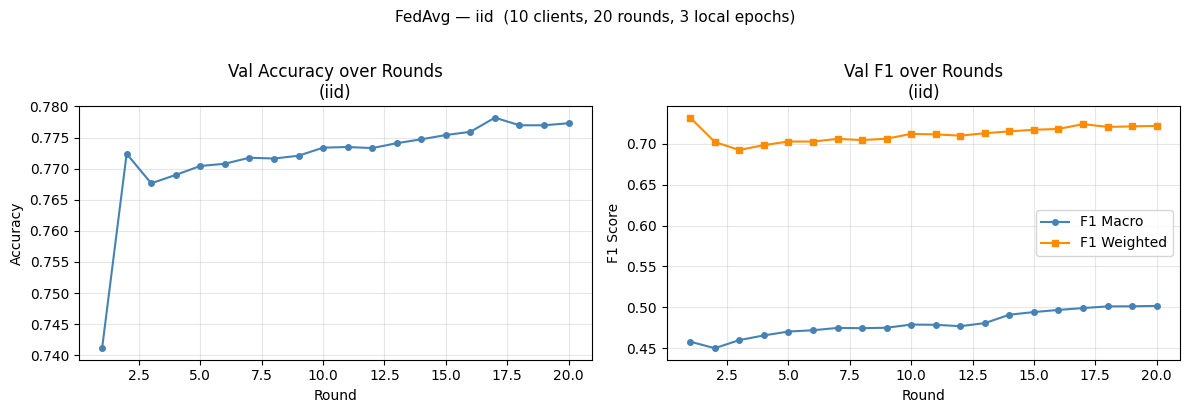

Saved → fedavg_curves_iid.png


In [8]:
rounds  = [e['round']       for e in round_log]
val_acc = [e['accuracy']    for e in round_log]
val_f1m = [e['f1_macro']    for e in round_log]
val_f1w = [e['f1_weighted'] for e in round_log]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rounds, val_acc, marker='o', linewidth=1.5, markersize=4, color='steelblue')
axes[0].set_title(f'Val Accuracy over Rounds\n({PARTITION_MODE})')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rounds, val_f1m, marker='o', linewidth=1.5, markersize=4, label='F1 Macro',    color='steelblue')
axes[1].plot(rounds, val_f1w, marker='s', linewidth=1.5, markersize=4, label='F1 Weighted', color='darkorange')
axes[1].set_title(f'Val F1 over Rounds\n({PARTITION_MODE})')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'FedAvg — {PARTITION_MODE}  ({NUM_CLIENTS} clients, {ROUNDS} rounds, {LOCAL_EPOCHS} local epochs)',
    fontsize=11, y=1.02
)
plt.tight_layout()

plot_path = PLOTS_DIR / f'fedavg_curves_{PARTITION_MODE}.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {plot_path.name}')

In [9]:
print('=== Final evaluation on TEST set ===\n')

y_test_pred = np.argmax(
    global_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0), axis=1
)

test_acc = float(accuracy_score(y_test, y_test_pred))
test_f1m = float(f1_score(y_test, y_test_pred, average='macro',    zero_division=0))
test_f1w = float(f1_score(y_test, y_test_pred, average='weighted', zero_division=0))

print(f'Test accuracy   : {test_acc:.4f}')
print(f'Test F1 macro   : {test_f1m:.4f}')
print(f'Test F1 weighted: {test_f1w:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# Per-class F1 for the summary JSON
per_class_f1  = f1_score(y_test, y_test_pred, average=None, zero_division=0)
per_class_dict = {cls: float(per_class_f1[i]) for i, cls in enumerate(class_names)}

final_metrics = {
    'partition_mode':     PARTITION_MODE,
    'num_clients':        NUM_CLIENTS,
    'rounds':             ROUNDS,
    'local_epochs':       LOCAL_EPOCHS,
    'batch_size':         BATCH_SIZE,
    'random_seed':        RANDOM_SEED,
    'test_accuracy':      test_acc,
    'test_f1_macro':      test_f1m,
    'test_f1_weighted':   test_f1w,
    'test_f1_per_class':  per_class_dict,
}

=== Final evaluation on TEST set ===

Test accuracy   : 0.7774
Test F1 macro   : 0.5053
Test F1 weighted: 0.7220

              precision    recall  f1-score   support

        DDoS       0.77      0.98      0.86   2458413
         DoS       0.68      0.12      0.21    835769
       Mirai       1.00      0.99      0.99    471837
      Benign       0.65      0.82      0.73    209462
       Recon       0.68      0.67      0.68    131093
    Spoofing       0.57      0.29      0.38     87212
         Web       0.00      0.00      0.00      4741
  BruteForce       0.89      0.11      0.19      2504

    accuracy                           0.78   4201031
   macro avg       0.65      0.50      0.51   4201031
weighted avg       0.76      0.78      0.72   4201031



In [10]:
# ── Round log ──────────────────────────────────────────────────────────
log_path = FEDAVG_DIR / f'fedavg_round_log_{PARTITION_MODE}.json'
with open(log_path, 'w') as f:
    json.dump(round_log, f, indent=2)
print(f'Round log        → {log_path}')

# ── Final metrics JSON ──────────────────────────────────────────────
metrics_json_path = RESULTS_DIR / f'fedavg_final_metrics_{PARTITION_MODE}.json'
with open(metrics_json_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f'Metrics JSON     → {metrics_json_path}')

# ── Final metrics CSV ───────────────────────────────────────────────
rows = (
    [{'metric': 'test_accuracy',    'value': final_metrics['test_accuracy']},
     {'metric': 'test_f1_macro',    'value': final_metrics['test_f1_macro']},
     {'metric': 'test_f1_weighted', 'value': final_metrics['test_f1_weighted']}]
    + [{'metric': f'f1_{cls}', 'value': v}
       for cls, v in final_metrics['test_f1_per_class'].items()]
)
metrics_csv_path = RESULTS_DIR / f'fedavg_final_metrics_{PARTITION_MODE}.csv'
pd.DataFrame(rows).to_csv(metrics_csv_path, index=False)
print(f'Metrics CSV      → {metrics_csv_path}')

print('\n── All outputs saved ──')
print(f'  fedavg/   {log_path.name}')
print(f'  results/  {metrics_json_path.name}')
print(f'  results/  {metrics_csv_path.name}')
print(f'  plots/    fedavg_curves_{PARTITION_MODE}.png')

Round log        → /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/fedavg/fedavg_round_log_iid.json
Metrics JSON     → /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/results/fedavg_final_metrics_iid.json
Metrics CSV      → /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/results/fedavg_final_metrics_iid.csv

── All outputs saved ──
  fedavg/   fedavg_round_log_iid.json
  results/  fedavg_final_metrics_iid.json
  results/  fedavg_final_metrics_iid.csv
  plots/    fedavg_curves_iid.png


## Next steps

1. **Run Non-IID variants** — change `PARTITION_MODE` in Cell 1 to `'dirichlet_03'` then `'dirichlet_01'` and re-run from Cell 1. Each run writes to its own output files.

2. **Compare convergence curves** — overlay the three `fedavg_curves_*.png` plots to see how heterogeneity slows convergence and degrades final F1-macro.

3. **Inspect per-class F1** — compare `test_f1_per_class` across partition modes. Minority classes (Web, BruteForce) are expected to degrade most under `dirichlet_01` because most clients have zero samples for those classes.

4. **Stage 2 summary** — once all three runs are complete, compare centralized baseline (Stage 1 MLP: test F1-macro 0.586) vs federated IID vs dirichlet_03 vs dirichlet_01. This gap is the cost of federation; the IID vs Non-IID gap is the cost of heterogeneity.